# FinBERT Sentiment Analysis on Financial News Headlines

This notebook implements sentiment analysis on financial news headlines using FinBERT, a specialized BERT model trained on financial text data. The analysis will help extract trading signals from news sentiment.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
import warnings
from tqdm import tqdm
import pickle
import os

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Suppress warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


/Users/nicolas/Desktop/Repos/zhaw_arep/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


In [2]:
# Load FinBERT model and tokenizer
print("Loading FinBERT model...")

# FinBERT model for sentiment analysis
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model loaded successfully on {device}")
print(f"Model: {model_name}")
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")


Loading FinBERT model...
Model loaded successfully on cpu
Model: ProsusAI/finbert
Tokenizer vocab size: 30522


## Load and Preprocess Data


In [3]:
# Load the datasets
print("Loading news datasets...")

cnbc_df = pd.read_csv('../data/raw/cnbc_headlines.csv')
guardian_df = pd.read_csv('../data/raw/guardian_headlines.csv')
reuters_df = pd.read_csv('../data/raw/reuters_headlines.csv')

# Add source labels
cnbc_df['source'] = 'CNBC'
guardian_df['source'] = 'The Guardian'
reuters_df['source'] = 'Reuters'

# Combine all datasets
df = pd.concat([cnbc_df, guardian_df, reuters_df], ignore_index=True)

print(f"Total headlines loaded: {len(df)}")
print(f"Sources: {df['source'].value_counts().to_dict()}")

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())


Loading news datasets...
Total headlines loaded: 53650
Sources: {'Reuters': 32770, 'The Guardian': 17800, 'CNBC': 3080}

Missing values:
Headlines        280
Time             280
Description    18080
source             0
dtype: int64


In [4]:
# Data preprocessing
print("Preprocessing data...")

# Remove rows with missing headlines
df_clean = df.dropna(subset=['Headlines']).copy()

# Clean headlines: remove extra whitespace and convert to string
df_clean['Headlines'] = df_clean['Headlines'].astype(str).str.strip()

# Remove empty headlines
df_clean = df_clean[df_clean['Headlines'] != ''].copy()

# Convert Time column to datetime
df_clean['Time'] = pd.to_datetime(df_clean['Time'], errors='coerce')

# Add text length for analysis
df_clean['headline_length'] = df_clean['Headlines'].str.len()

print(f"After cleaning: {len(df_clean)} headlines")
print(f"Date range: {df_clean['Time'].min()} to {df_clean['Time'].max()}")

# Display sample headlines
print(f"\nSample headlines:")
for i, row in df_clean.head(3).iterrows():
    print(f"{i+1}. [{row['source']}] {row['Headlines']}")


Preprocessing data...
After cleaning: 53370 headlines
Date range: 2017-12-17 00:00:00 to 2020-07-18 00:00:00

Sample headlines:
1. [CNBC] Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush
2. [CNBC] Cramer's lightning round: I would own Teradyne
4. [CNBC] Cramer's week ahead: Big week for earnings, even bigger week for vaccines


## Sentiment Analysis Functions


In [5]:
# Define sentiment analysis function
def analyze_sentiment(text, tokenizer, model, device):
    """
    Analyze sentiment of a single text using FinBERT
    
    Returns:
        dict: Contains sentiment label and confidence scores
    """
    # Tokenize the text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    # FinBERT labels: 0=positive, 1=negative, 2=neutral
    labels = ['positive', 'negative', 'neutral']
    scores = predictions.cpu().numpy()[0]
    
    # Get the predicted label and confidence
    predicted_label = labels[np.argmax(scores)]
    confidence = float(np.max(scores))
    
    return {
        'sentiment': predicted_label,
        'confidence': confidence,
        'positive_score': float(scores[0]),
        'negative_score': float(scores[1]),
        'neutral_score': float(scores[2])
    }

# Test the function with a sample headline
sample_text = "Stock market rallies as investors show optimism about economic recovery"
sample_result = analyze_sentiment(sample_text, tokenizer, model, device)

print("Sample sentiment analysis:")
print(f"Text: {sample_text}")
print(f"Sentiment: {sample_result['sentiment']}")
print(f"Confidence: {sample_result['confidence']:.3f}")
print(f"Scores - Positive: {sample_result['positive_score']:.3f}, "
      f"Negative: {sample_result['negative_score']:.3f}, "
      f"Neutral: {sample_result['neutral_score']:.3f}")


Sample sentiment analysis:
Text: Stock market rallies as investors show optimism about economic recovery
Sentiment: positive
Confidence: 0.758
Scores - Positive: 0.758, Negative: 0.119, Neutral: 0.122


In [6]:
# Batch processing function for efficiency
def batch_sentiment_analysis(texts, tokenizer, model, device, batch_size=32):
    """
    Analyze sentiment for a batch of texts efficiently
    
    Args:
        texts: List of text strings
        tokenizer: FinBERT tokenizer
        model: FinBERT model
        device: torch device
        batch_size: Number of texts to process at once
    
    Returns:
        List of sentiment analysis results
    """
    results = []
    
    # Process in batches
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing batches"):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            truncation=True, 
            padding=True, 
            max_length=512
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Get predictions
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        
        # Process results
        labels = ['positive', 'negative', 'neutral']
        batch_scores = predictions.cpu().numpy()
        
        for scores in batch_scores:
            predicted_label = labels[np.argmax(scores)]
            confidence = float(np.max(scores))
            
            results.append({
                'sentiment': predicted_label,
                'confidence': confidence,
                'positive_score': float(scores[0]),
                'negative_score': float(scores[1]),
                'neutral_score': float(scores[2])
            })
    
    return results

print("Batch processing function defined successfully!")


Batch processing function defined successfully!


## Run Sentiment Analysis


In [7]:
# Run sentiment analysis on all headlines
print("Starting sentiment analysis on all headlines...")
print(f"Processing {len(df_clean)} headlines...")

# Extract headlines for processing
headlines = df_clean['Headlines'].tolist()

# Run batch sentiment analysis
sentiment_results = batch_sentiment_analysis(
    headlines, 
    tokenizer, 
    model, 
    device, 
    batch_size=16  # Adjust batch size based on your GPU memory
)

print(f"\nSentiment analysis completed!")
print(f"Processed {len(sentiment_results)} headlines")


Starting sentiment analysis on all headlines...
Processing 53370 headlines...


Processing batches: 100%|██████████| 3336/3336 [06:49<00:00,  8.14it/s]


Sentiment analysis completed!
Processed 53370 headlines


In [8]:
# Add sentiment results to the dataframe
print("Adding sentiment results to dataframe...")

# Convert results to DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

# Combine with original data
df_with_sentiment = df_clean.reset_index(drop=True).copy()
df_with_sentiment = pd.concat([df_with_sentiment, sentiment_df], axis=1)

# Create a composite sentiment score (-1 to 1 scale)
# positive=1, negative=-1, neutral=0, weighted by confidence
def create_sentiment_score(row):
    if row['sentiment'] == 'positive':
        return row['confidence']
    elif row['sentiment'] == 'negative':
        return -row['confidence']
    else:  # neutral
        return 0

df_with_sentiment['sentiment_score'] = df_with_sentiment.apply(create_sentiment_score, axis=1)

print(f"DataFrame shape: {df_with_sentiment.shape}")
print(f"Columns: {list(df_with_sentiment.columns)}")

# Display sample results
print(f"\nSample sentiment results:")
sample_cols = ['Headlines', 'source', 'sentiment', 'confidence', 'sentiment_score']
print(df_with_sentiment[sample_cols].head(10))


Adding sentiment results to dataframe...
DataFrame shape: (53370, 11)
Columns: ['Headlines', 'Time', 'Description', 'source', 'headline_length', 'sentiment', 'confidence', 'positive_score', 'negative_score', 'neutral_score', 'sentiment_score']

Sample sentiment results:
                                           Headlines source sentiment  \
0  Jim Cramer: A better way to invest in the Covi...   CNBC   neutral   
1     Cramer's lightning round: I would own Teradyne   CNBC   neutral   
2  Cramer's week ahead: Big week for earnings, ev...   CNBC   neutral   
3  IQ Capital CEO Keith Bliss says tech and healt...   CNBC  positive   
4  Wall Street delivered the 'kind of pullback I'...   CNBC  positive   
5  Cramer's lightning round: I would just stay lo...   CNBC   neutral   
6  Acorns CEO: Parents can turn $5 into five figu...   CNBC   neutral   
7  Dividend cuts may mean rethinking your retirem...   CNBC  negative   
8  StockX has authenticated 1 million Jordan snea...   CNBC   neutral   

## Sentiment Analysis Results


In [9]:
# Overall sentiment distribution
print("=== OVERALL SENTIMENT DISTRIBUTION ===")
sentiment_counts = df_with_sentiment['sentiment'].value_counts()
sentiment_percentages = df_with_sentiment['sentiment'].value_counts(normalize=True) * 100

for sentiment in ['positive', 'negative', 'neutral']:
    count = sentiment_counts.get(sentiment, 0)
    percentage = sentiment_percentages.get(sentiment, 0)
    print(f"{sentiment.capitalize()}: {count:,} ({percentage:.1f}%)")

print(f"\nTotal headlines analyzed: {len(df_with_sentiment):,}")

# Average confidence scores
avg_confidence = df_with_sentiment['confidence'].mean()
print(f"Average confidence: {avg_confidence:.3f}")

# Sentiment score statistics
print(f"\nSentiment Score Statistics:")
print(f"Mean: {df_with_sentiment['sentiment_score'].mean():.3f}")
print(f"Median: {df_with_sentiment['sentiment_score'].median():.3f}")
print(f"Std: {df_with_sentiment['sentiment_score'].std():.3f}")
print(f"Min: {df_with_sentiment['sentiment_score'].min():.3f}")
print(f"Max: {df_with_sentiment['sentiment_score'].max():.3f}")


=== OVERALL SENTIMENT DISTRIBUTION ===
Positive: 9,436 (17.7%)
Negative: 20,474 (38.4%)
Neutral: 23,460 (44.0%)

Total headlines analyzed: 53,370
Average confidence: 0.806

Sentiment Score Statistics:
Mean: -0.186
Median: 0.000
Std: 0.592
Min: -0.977
Max: 0.959


In [10]:
# Sentiment distribution by source
print("=== SENTIMENT BY SOURCE ===")
source_sentiment = pd.crosstab(df_with_sentiment['source'], df_with_sentiment['sentiment'], normalize='index') * 100
print(source_sentiment.round(1))

# Average sentiment scores by source
print(f"\nAverage Sentiment Scores by Source:")
source_scores = df_with_sentiment.groupby('source')['sentiment_score'].agg(['mean', 'std', 'count'])
print(source_scores.round(3))


=== SENTIMENT BY SOURCE ===
sentiment     negative  neutral  positive
source                                   
CNBC              18.2     61.7      20.1
Reuters           37.6     41.6      20.8
The Guardian      42.9     45.5      11.6

Average Sentiment Scores by Source:
               mean    std  count
source                           
CNBC          0.008  0.494   2800
Reuters      -0.156  0.613  32770
The Guardian -0.273  0.553  17800


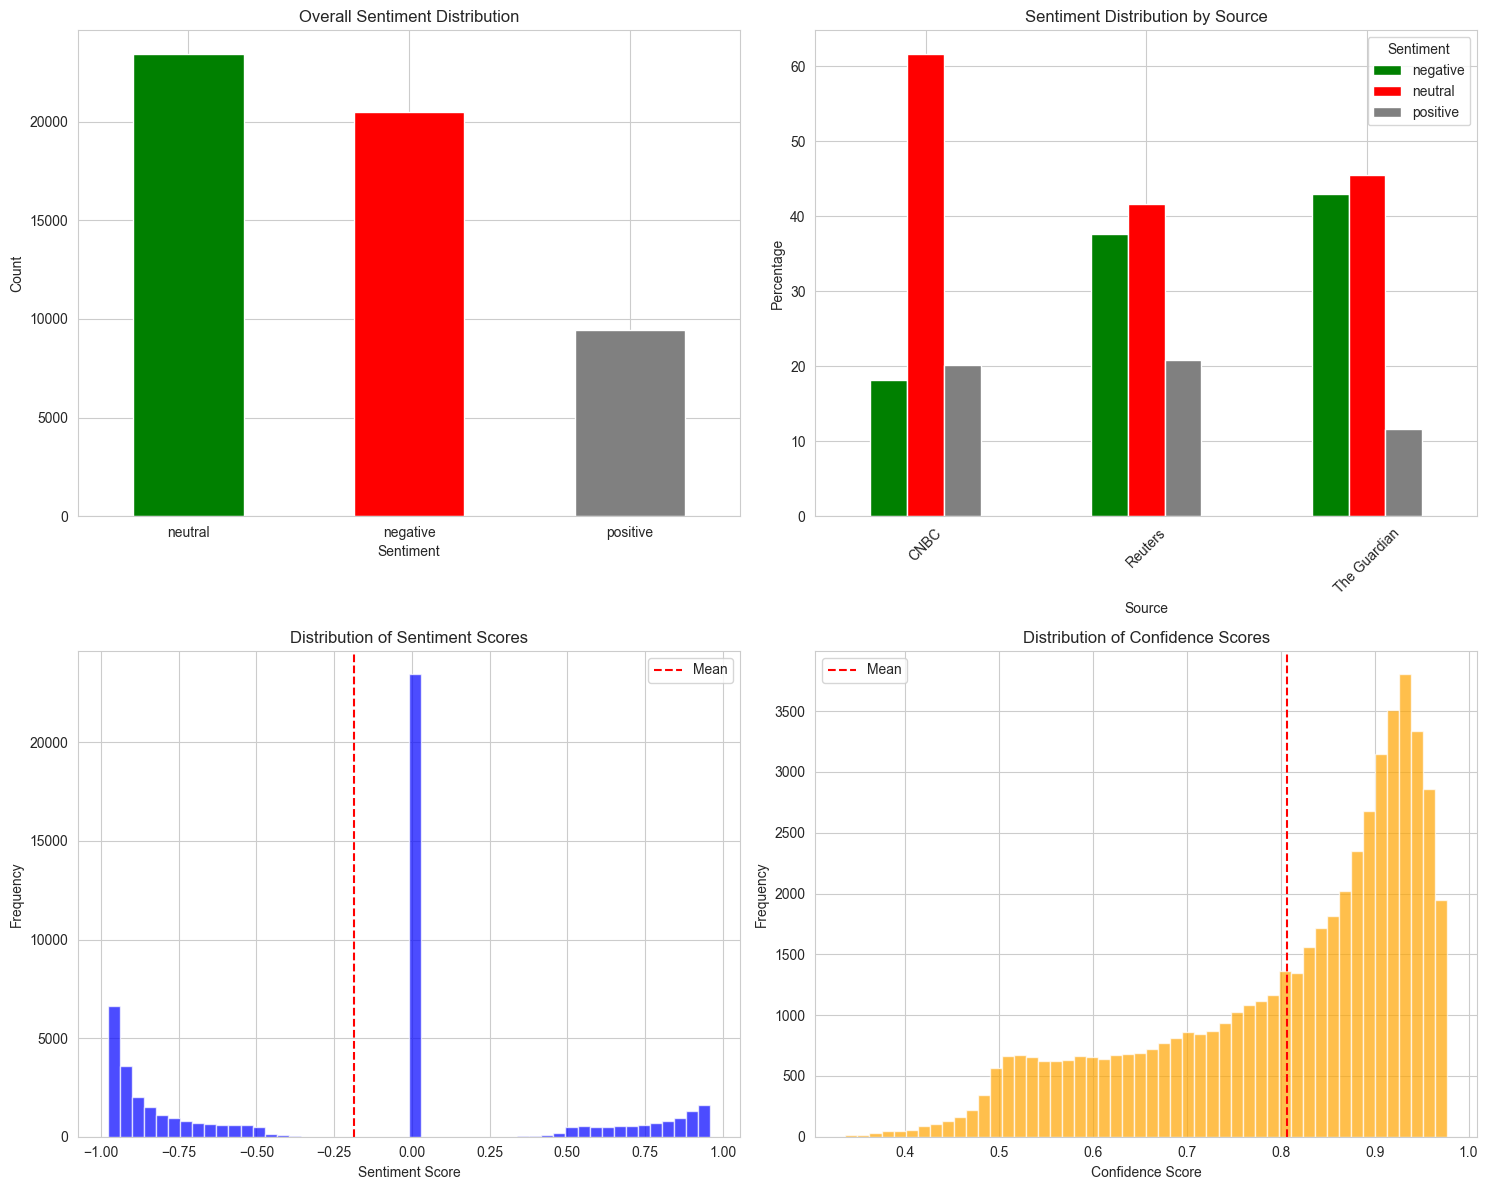

In [11]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Overall sentiment distribution
sentiment_counts.plot(kind='bar', ax=axes[0,0], color=['green', 'red', 'gray'])
axes[0,0].set_title('Overall Sentiment Distribution')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Sentiment distribution by source
source_sentiment.plot(kind='bar', ax=axes[0,1], color=['green', 'red', 'gray'])
axes[0,1].set_title('Sentiment Distribution by Source')
axes[0,1].set_xlabel('Source')
axes[0,1].set_ylabel('Percentage')
axes[0,1].legend(title='Sentiment')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Sentiment score distribution
axes[1,0].hist(df_with_sentiment['sentiment_score'], bins=50, alpha=0.7, color='blue')
axes[1,0].set_title('Distribution of Sentiment Scores')
axes[1,0].set_xlabel('Sentiment Score')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(df_with_sentiment['sentiment_score'].mean(), color='red', linestyle='--', label='Mean')
axes[1,0].legend()

# 4. Confidence distribution
axes[1,1].hist(df_with_sentiment['confidence'], bins=50, alpha=0.7, color='orange')
axes[1,1].set_title('Distribution of Confidence Scores')
axes[1,1].set_xlabel('Confidence Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(df_with_sentiment['confidence'].mean(), color='red', linestyle='--', label='Mean')
axes[1,1].legend()

plt.tight_layout()
plt.show()


In [12]:
# Show examples of different sentiment categories
print("=== SAMPLE HEADLINES BY SENTIMENT ===")

for sentiment in ['positive', 'negative', 'neutral']:
    print(f"\n--- {sentiment.upper()} HEADLINES ---")
    sample_headlines = df_with_sentiment[df_with_sentiment['sentiment'] == sentiment].head(3)
    
    for idx, row in sample_headlines.iterrows():
        print(f"[{row['source']}] {row['Headlines']}")
        print(f"  Confidence: {row['confidence']:.3f}, Score: {row['sentiment_score']:.3f}")
        print()


=== SAMPLE HEADLINES BY SENTIMENT ===

--- POSITIVE HEADLINES ---
[CNBC] IQ Capital CEO Keith Bliss says tech and healthcare will rally
  Confidence: 0.856, Score: 0.856

[CNBC] Wall Street delivered the 'kind of pullback I've been waiting for,' Jim Cramer says
  Confidence: 0.898, Score: 0.898

[CNBC] Biohaven Pharmaceuticals lands Khloe Kardashian as influencer of new migraine drug
  Confidence: 0.798, Score: 0.798


--- NEGATIVE HEADLINES ---
[CNBC] Dividend cuts may mean rethinking your retirement income strategy
  Confidence: 0.871, Score: -0.871

[CNBC] Charts suggest the S&P 500 climb will stall out at the end of July, Jim Cramer warns
  Confidence: 0.960, Score: -0.960

[CNBC] Ellevest's Sallie Krawcheck says the economic crisis has caused a 'she-cession'
  Confidence: 0.957, Score: -0.957


--- NEUTRAL HEADLINES ---
[CNBC] Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush
  Confidence: 0.679, Score: 0.000

[CNBC] Cramer's lightning round: I would own Teradyn

## Save Results for Further Analysis


In [13]:
# Create processed data directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Save the complete dataset with sentiment analysis
output_file = '../data/processed/news_with_sentiment.csv'
df_with_sentiment.to_csv(output_file, index=False)

print(f"Data saved to: {output_file}")
print(f"Shape: {df_with_sentiment.shape}")

# Save a summary statistics file
summary_stats = {
    'total_headlines': len(df_with_sentiment),
    'sentiment_distribution': df_with_sentiment['sentiment'].value_counts().to_dict(),
    'sentiment_percentages': df_with_sentiment['sentiment'].value_counts(normalize=True).to_dict(),
    'average_confidence': float(df_with_sentiment['confidence'].mean()),
    'sentiment_score_stats': {
        'mean': float(df_with_sentiment['sentiment_score'].mean()),
        'std': float(df_with_sentiment['sentiment_score'].std()),
        'min': float(df_with_sentiment['sentiment_score'].min()),
        'max': float(df_with_sentiment['sentiment_score'].max())
    },
    'source_distribution': df_with_sentiment['source'].value_counts().to_dict()
}

# Save summary as pickle for easy loading
summary_file = '../data/processed/sentiment_summary.pkl'
with open(summary_file, 'wb') as f:
    pickle.dump(summary_stats, f)

print(f"Summary statistics saved to: {summary_file}")

# Display final summary
print(f"\n=== FINAL SUMMARY ===")
print(f"Total headlines processed: {summary_stats['total_headlines']:,}")
print(f"Sentiment distribution:")
for sentiment, count in summary_stats['sentiment_distribution'].items():
    percentage = summary_stats['sentiment_percentages'][sentiment] * 100
    print(f"  {sentiment.capitalize()}: {count:,} ({percentage:.1f}%)")
print(f"Average confidence: {summary_stats['average_confidence']:.3f}")
print(f"Average sentiment score: {summary_stats['sentiment_score_stats']['mean']:.3f}")


Data saved to: ../data/processed/news_with_sentiment.csv
Shape: (53370, 11)
Summary statistics saved to: ../data/processed/sentiment_summary.pkl

=== FINAL SUMMARY ===
Total headlines processed: 53,370
Sentiment distribution:
  Neutral: 23,460 (44.0%)
  Negative: 20,474 (38.4%)
  Positive: 9,436 (17.7%)
Average confidence: 0.806
Average sentiment score: -0.186


## Trading Signal Preparation

The sentiment analysis results can now be used to extract trading signals. Here are some key insights for signal generation:

### Key Metrics for Trading Signals:
1. **Sentiment Score**: Composite score from -1 (very negative) to +1 (very positive)
2. **Confidence**: Model confidence in the sentiment prediction
3. **Temporal Patterns**: Sentiment changes over time
4. **Source Weighting**: Different news sources may have different predictive power

### Next Steps:
- Use the processed data in `03_ticker_extraction.ipynb` to extract stock tickers
- Implement time-series analysis of sentiment trends
- Create trading signals based on sentiment momentum and thresholds
- Backtest strategies using the sentiment data
